# Week 04 – Image Processing Assignment

## Topics Covered
- Power Law Transformation (Gamma Correction)
- Image Negative
- Gamma Curves Analysis
- Intensity Range Mapping
- Practical Image Enhancement Techniques


---

## Environment Setup

OpenCV: 4.13.0
Image shape: (360, 640, 3) | dtype: uint8


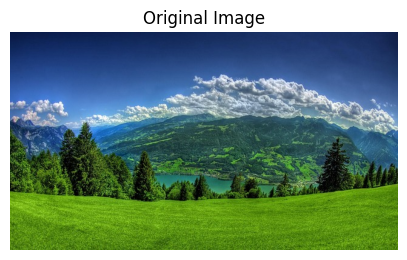

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("OpenCV:", cv2.__version__)

IMAGE_PATH = "nature.jpg"

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print("Image shape:", img.shape, "| dtype:", img.dtype)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

# Part 1 – Power Law Transformation (Gamma Correction)

### Challenge 1.1

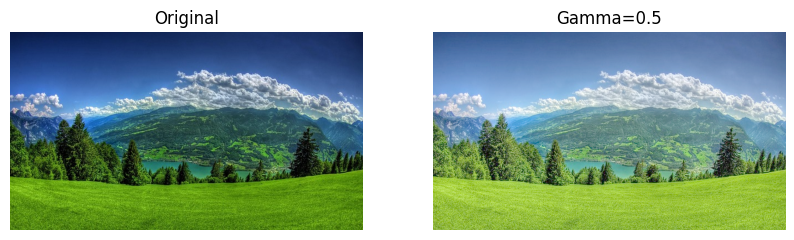

In [2]:
# Implement gamma_correction function

def gamma_correction(image, gamma):
    img_float = image.astype(np.float32) / 255.0
    corrected = np.power(img_float, gamma)
    corrected = (corrected * 255).astype(np.uint8)
    return corrected

img_gamma = gamma_correction(img, 0.5)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img_gamma); plt.title("Gamma=0.5"); plt.axis('off')
plt.show()

### Challenge 1.2 – Gamma Curve Analysis

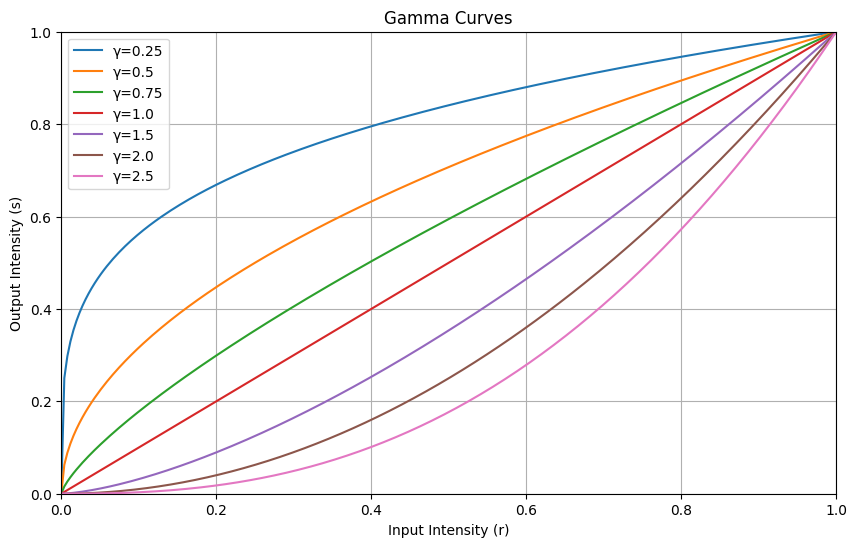

In [3]:
# Plot gamma curves

r = np.linspace(0, 1, 256)

gamma_values = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5]

plt.figure(figsize=(10,6))
for g in gamma_values:
    s = np.power(r, g)
    plt.plot(r, s, label=f'γ={g}')

plt.xlabel('Input Intensity (r)')
plt.ylabel('Output Intensity (s)')
plt.title('Gamma Curves')
plt.legend()
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

### Challenge 1.3 – Comparative Study

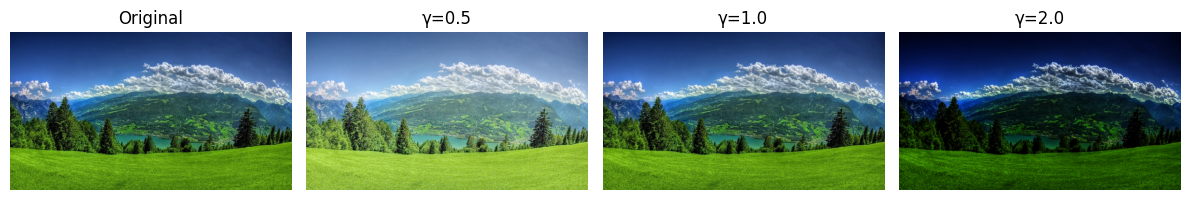

In [4]:
# Comparative gamma correction implementation

gamma_test = [0.5, 1.0, 2.0]

plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.imshow(img); plt.title("Original"); plt.axis('off')

for i, g in enumerate(gamma_test, start=2):
    img_g = gamma_correction(img, g)
    plt.subplot(1,4,i); plt.imshow(img_g); plt.title(f'γ={g}'); plt.axis('off')

plt.tight_layout()
plt.show()

# Part 2 – Basic Intensity Transformations

### Challenge 2.1 – Image Negative

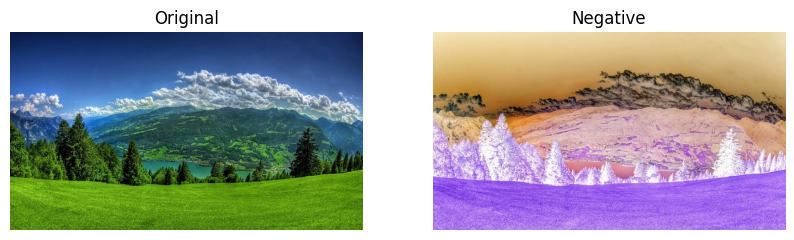

In [5]:
# Implement image negative transformation

def image_negative(image):
    max_val = 255
    negative = max_val - image
    return negative

img_negative = image_negative(img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img_negative); plt.title("Negative"); plt.axis('off')
plt.show()

### Challenge 2.2 – Intensity Range Mapping

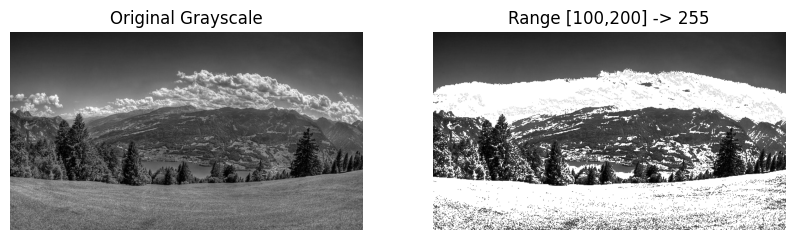

In [6]:
# Implement intensity range mapping

def intensity_range_mapping(image, A, B):
    result = image.copy()
    result[(image >= A) & (image <= B)] = 255
    return result

gray_for_mapping = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img_mapped = intensity_range_mapping(gray_for_mapping, 100, 200)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(gray_for_mapping, cmap='gray'); plt.title("Original Grayscale"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img_mapped, cmap='gray'); plt.title("Range [100,200] -> 255"); plt.axis('off')
plt.show()

### Challenge 2.3 – Integrated Enhancement

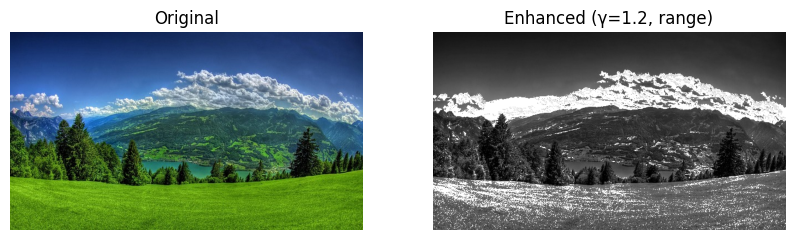

In [7]:
# Build full enhancement pipeline

def enhancement_pipeline(image, gamma=1.0, range_A=None, range_B=None):
    img_gamma = gamma_correction(image, gamma)
    
    if range_A is not None and range_B is not None:
        gray = cv2.cvtColor(img_gamma, cv2.COLOR_RGB2GRAY)
        img_gamma = intensity_range_mapping(gray, range_A, range_B)
    
    return img_gamma

final_result = enhancement_pipeline(img, gamma=1.2, range_A=120, range_B=200)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(final_result, cmap='gray'); plt.title("Enhanced (γ=1.2, range)"); plt.axis('off')
plt.show()

# Part 3 – Advanced Optimization Challenge

### Challenge 3.1 – Performance & Robustness

In [8]:
# Final optimized solution with input validation

def robust_gamma_correction(image, gamma):
    if image is None:
        raise ValueError("Image is None")
    if gamma <= 0:
        raise ValueError("Gamma must be positive")
    
    if len(image.shape) == 2:
        img_float = image.astype(np.float32) / 255.0
        corrected = np.power(img_float, gamma)
        return (corrected * 255).astype(np.uint8)
    else:
        result = np.zeros_like(image)
        for i in range(image.shape[2]):
            img_float = image[:,:,i].astype(np.float32) / 255.0
            corrected = np.power(img_float, gamma)
            result[:,:,i] = (corrected * 255).astype(np.uint8)
        return result

def robust_image_negative(image):
    if image is None:
        raise ValueError("Image is None")
    max_val = 255
    return max_val - image

def robust_intensity_mapping(image, A, B):
    if image is None:
        raise ValueError("Image is None")
    if A > B:
        raise ValueError("A must be <= B")
    result = image.copy()
    if len(image.shape) == 2:
        result[(image >= A) & (image <= B)] = 255
    else:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        mask = (gray >= A) & (gray <= B)
        for i in range(image.shape[2]):
            result[:,:,i][mask] = 255
    return result

print("All robust functions defined successfully!")

All robust functions defined successfully!


### Final Task: Complete Enhancement Solution

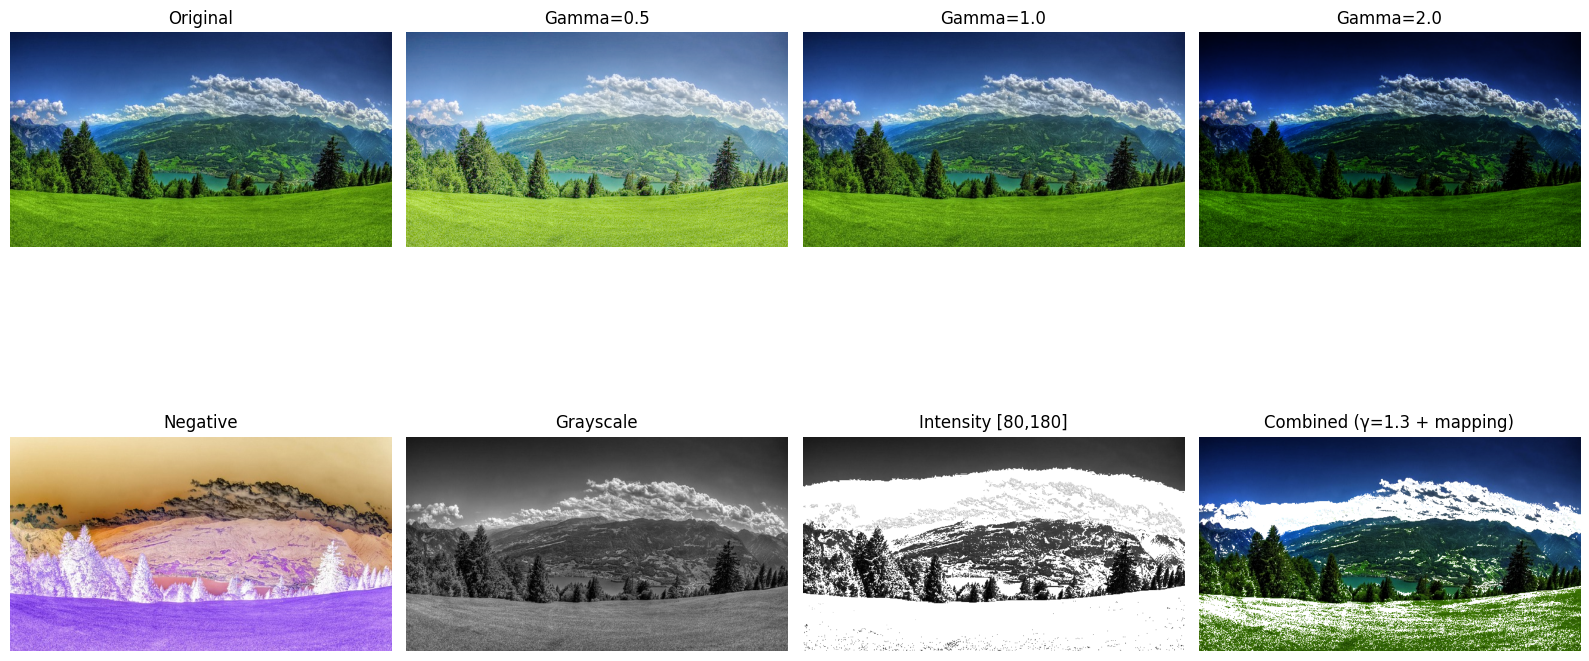

In [9]:
# Final comparison visualization

plt.figure(figsize=(16,10))

plt.subplot(2,4,1); plt.imshow(img); plt.title("Original"); plt.axis('off')

gamma_vals = [0.5, 1.0, 2.0]
for i, g in enumerate(gamma_vals, start=2):
    img_g = robust_gamma_correction(img, g)
    plt.subplot(2,4,i); plt.imshow(img_g); plt.title(f'Gamma={g}'); plt.axis('off')

plt.subplot(2,4,5); plt.imshow(robust_image_negative(img)); plt.title("Negative"); plt.axis('off')

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.subplot(2,4,6); plt.imshow(gray, cmap='gray'); plt.title("Grayscale"); plt.axis('off')

plt.subplot(2,4,7); plt.imshow(robust_intensity_mapping(gray, 80, 180), cmap='gray'); plt.title("Intensity [80,180]"); plt.axis('off')

img_combined = robust_gamma_correction(img, 1.3)
img_combined = robust_intensity_mapping(img_combined, 100, 220)
plt.subplot(2,4,8); plt.imshow(img_combined); plt.title("Combined (γ=1.3 + mapping)"); plt.axis('off')

plt.tight_layout()
plt.show()